C:\Users\martin\AppData\Local\Temp\ipykernel_15024\2470900795.py:73: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


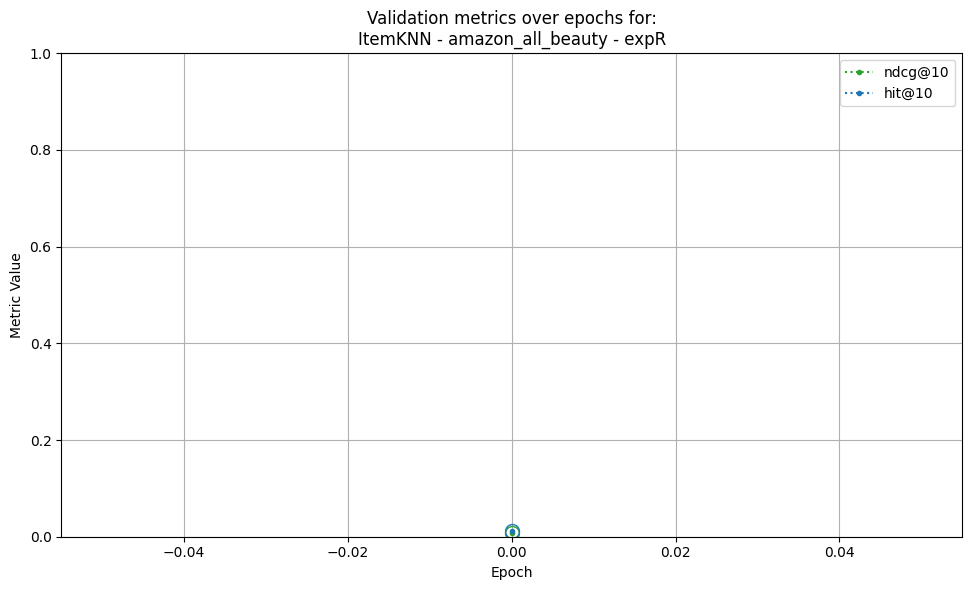

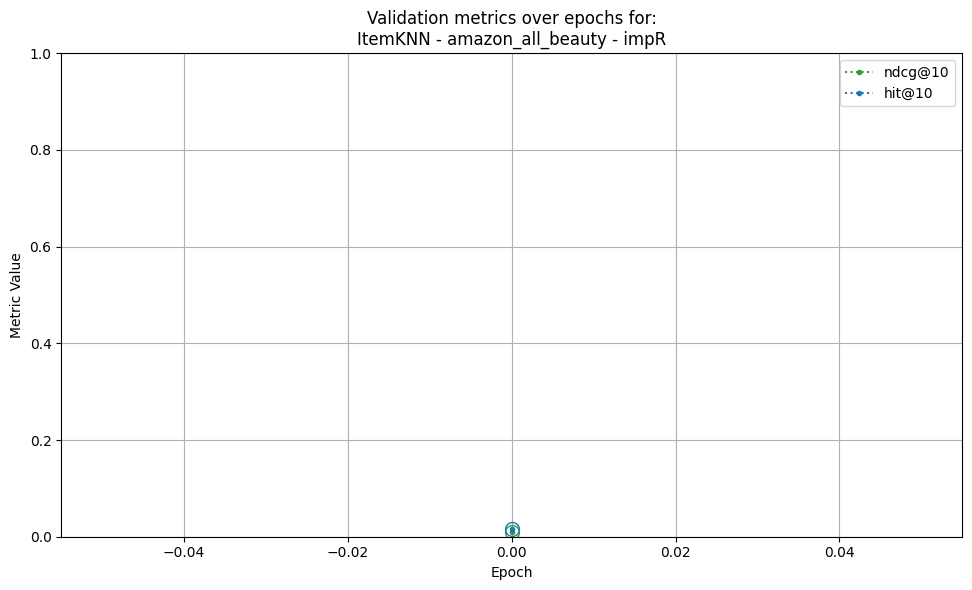

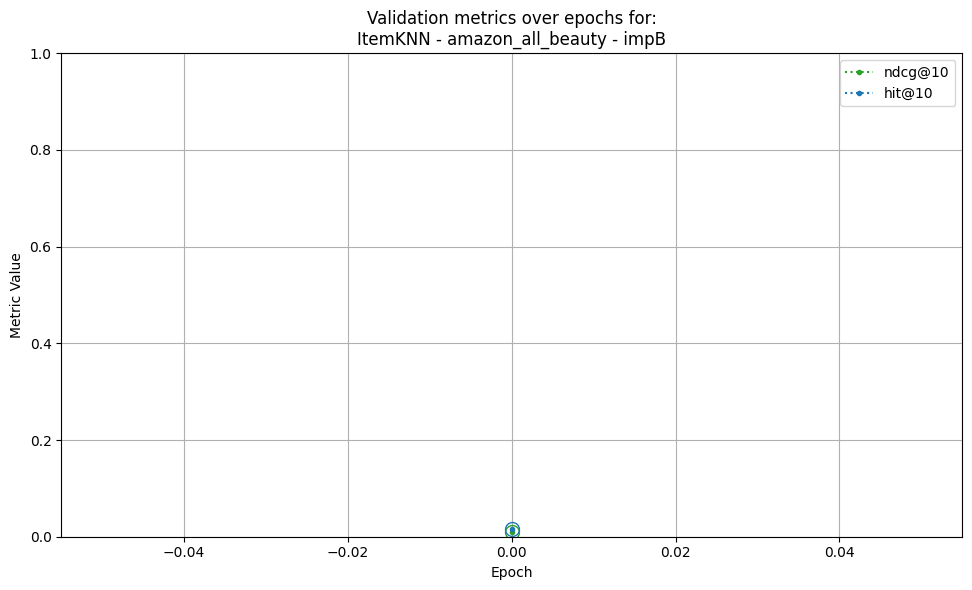

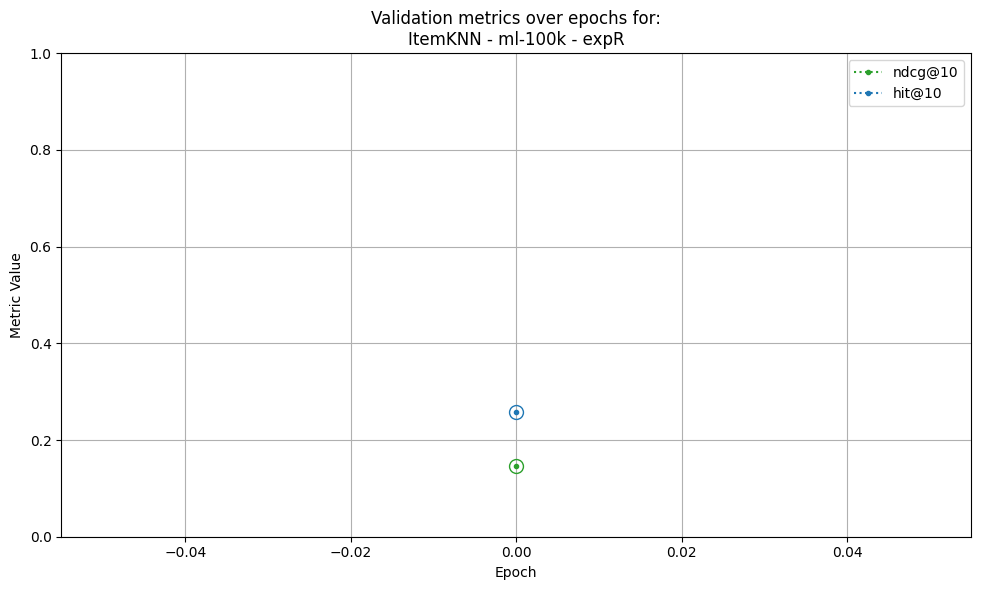

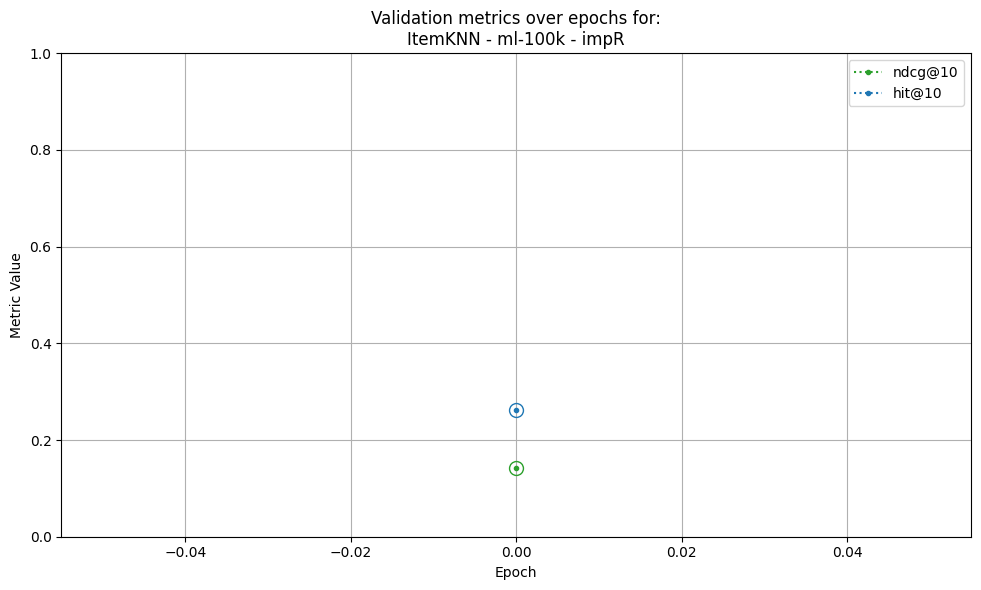

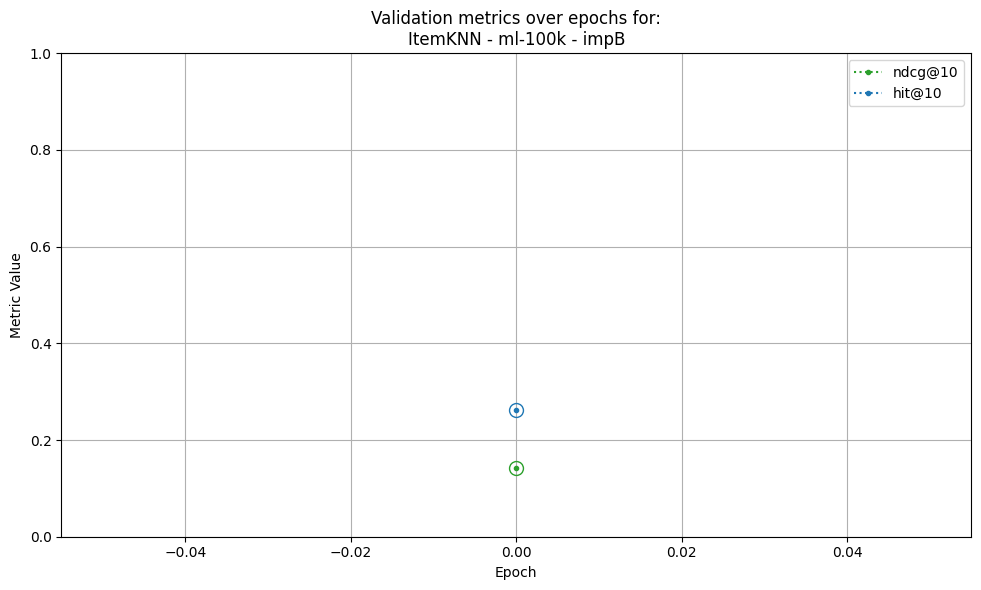

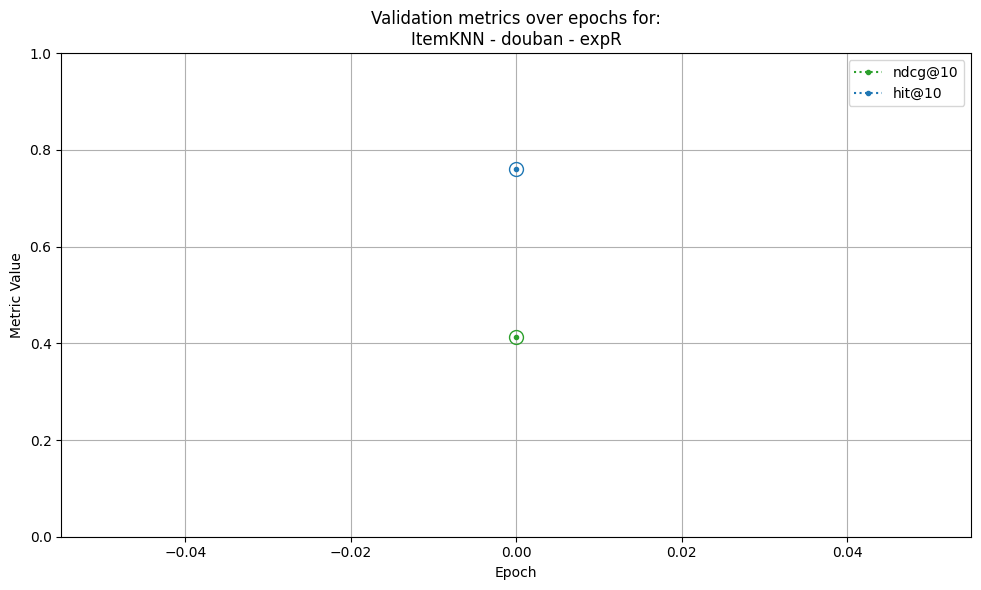

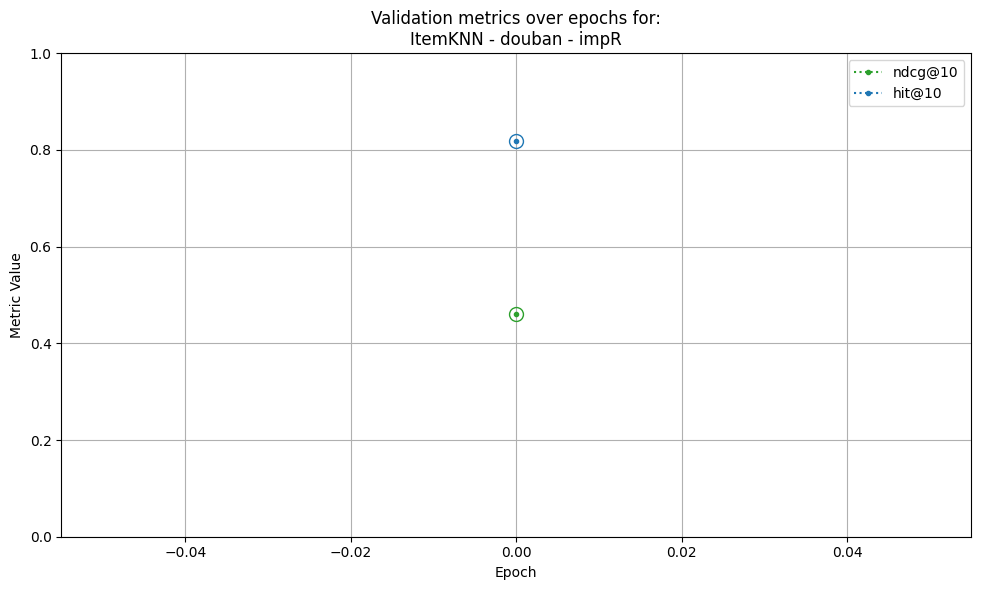

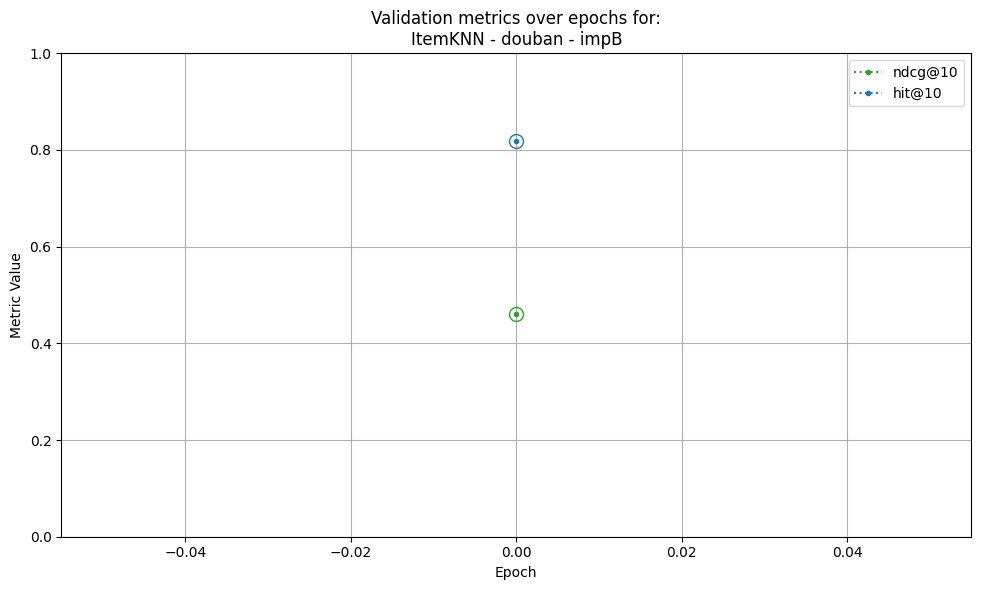

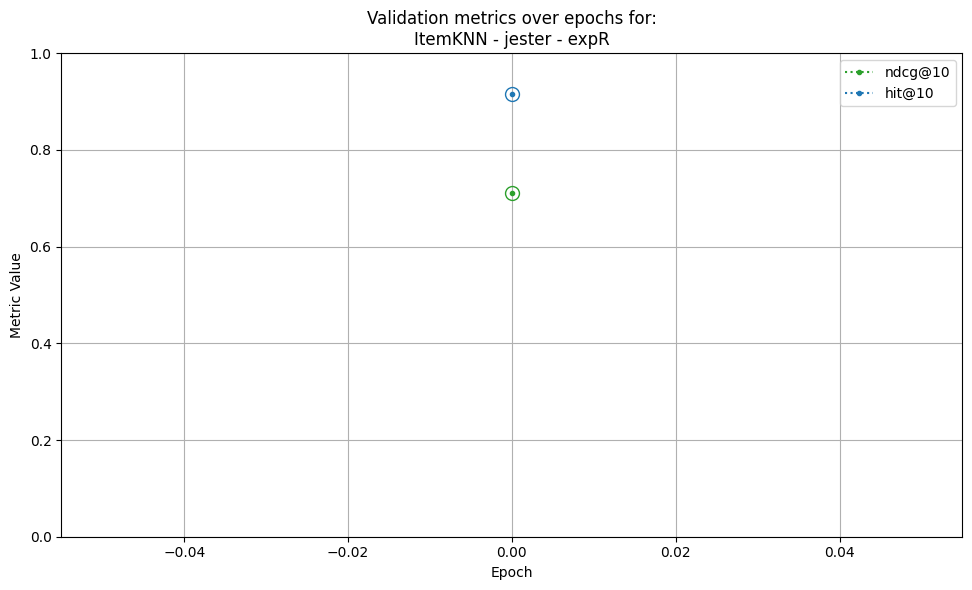

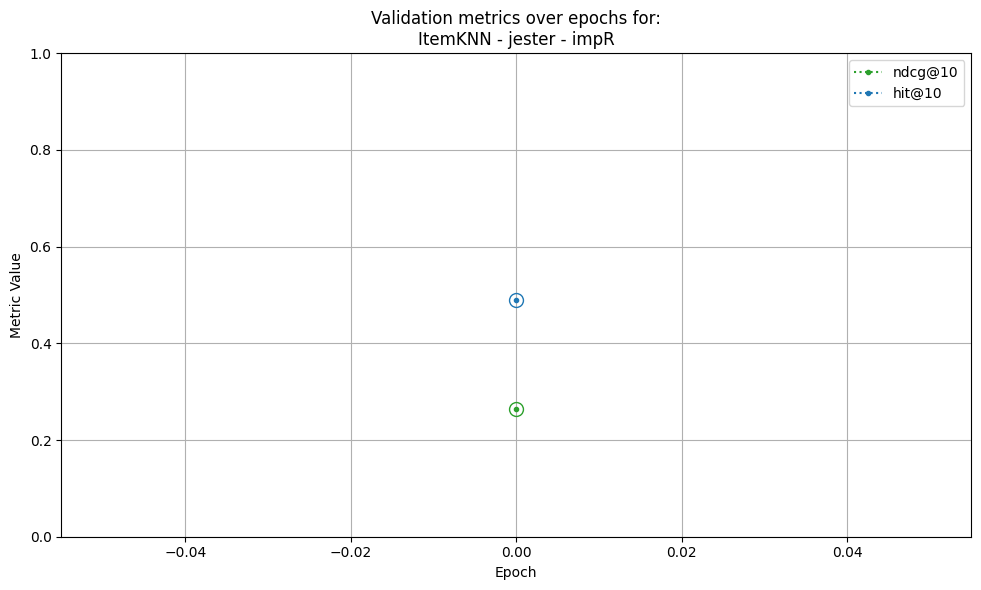

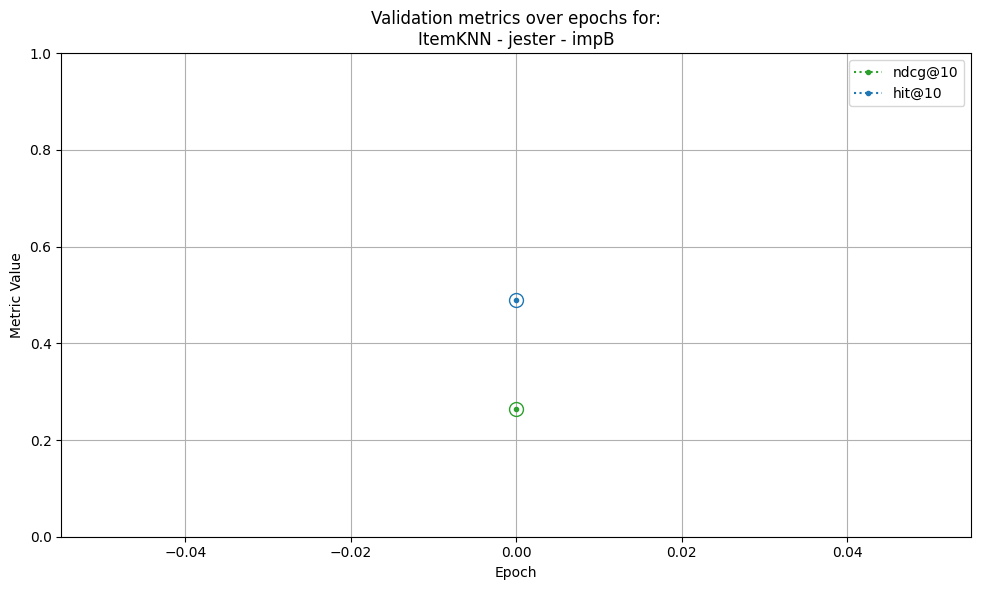

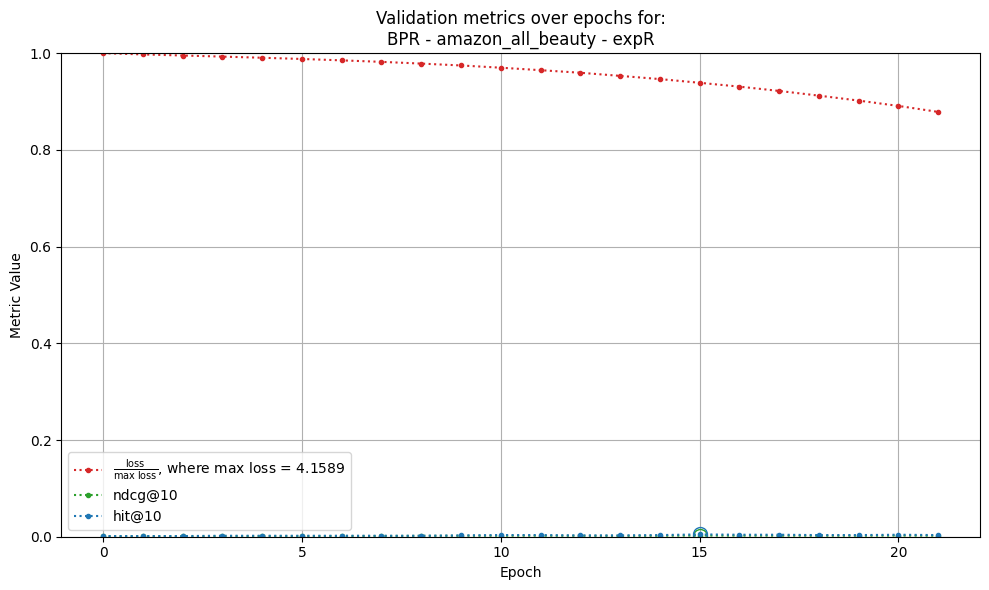

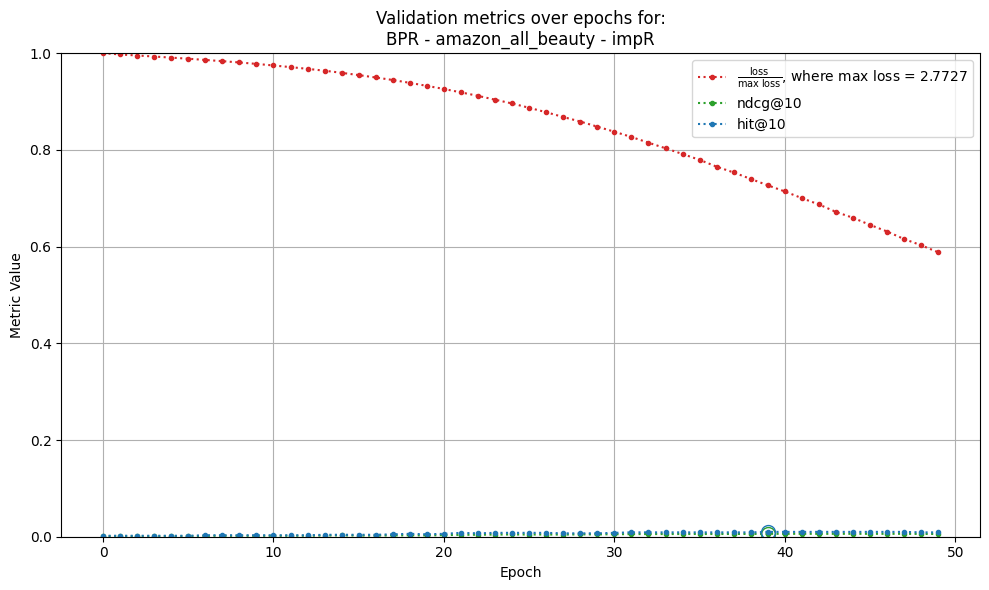

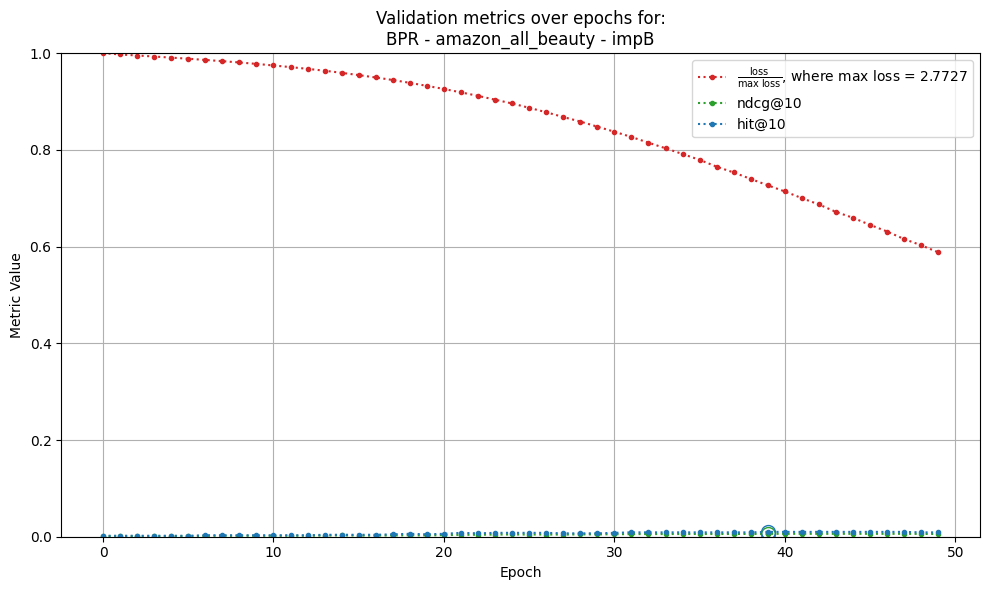

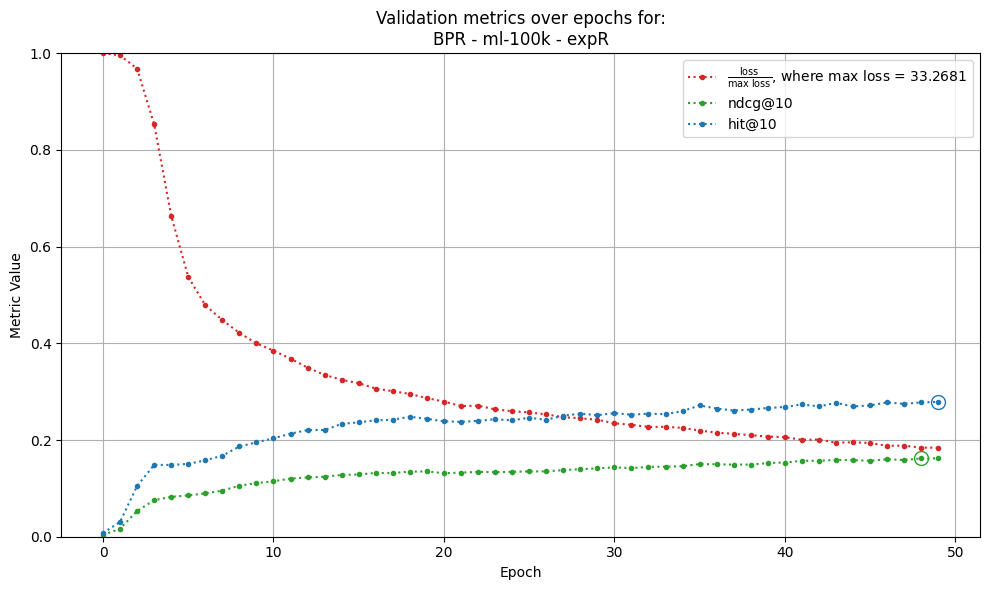

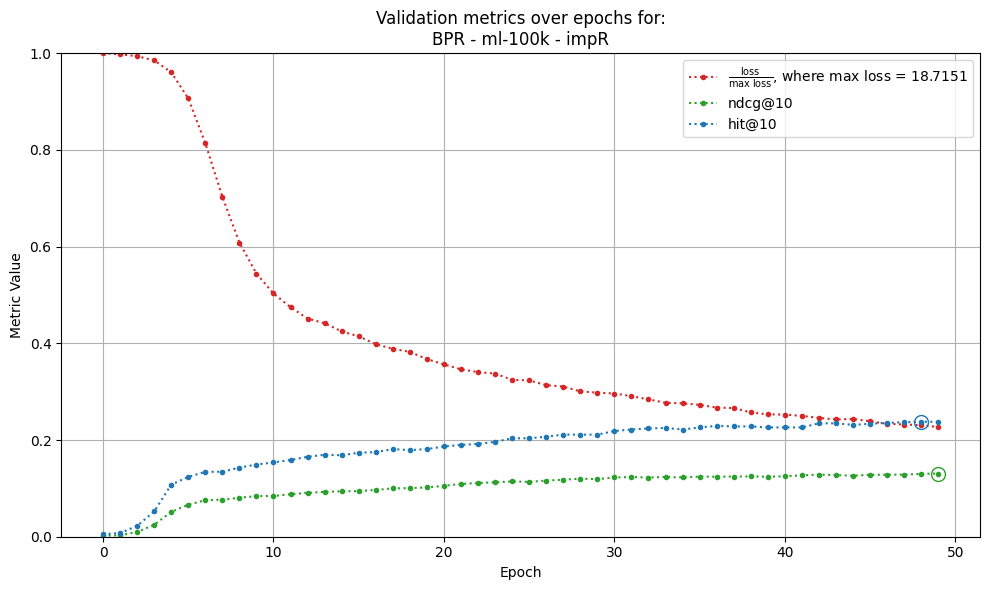

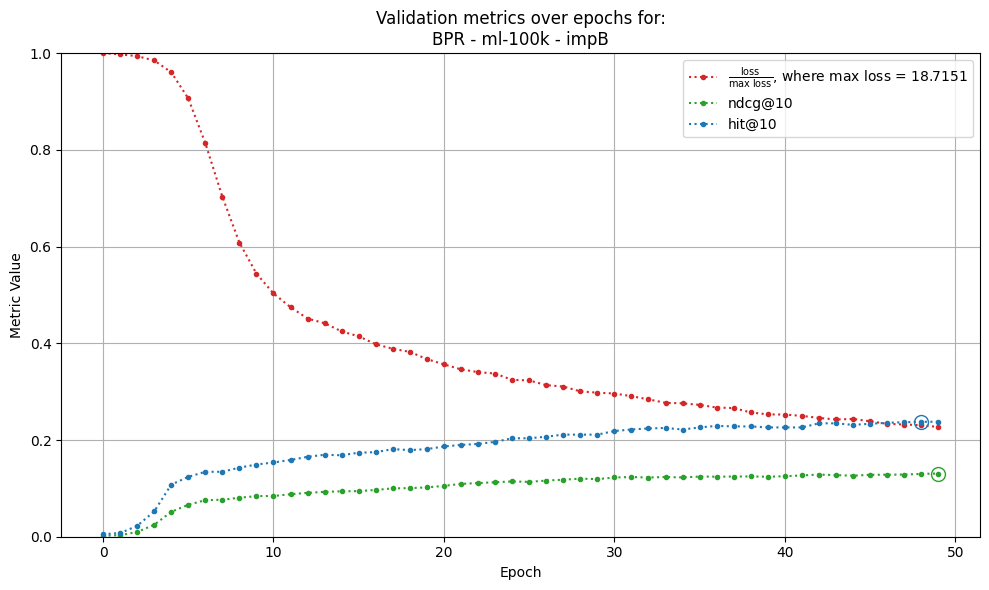

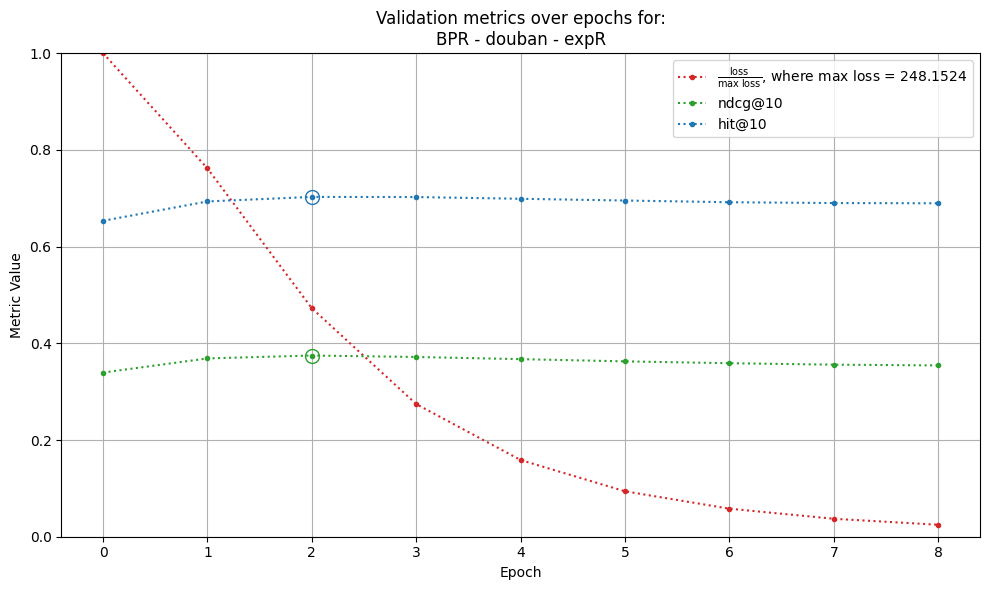

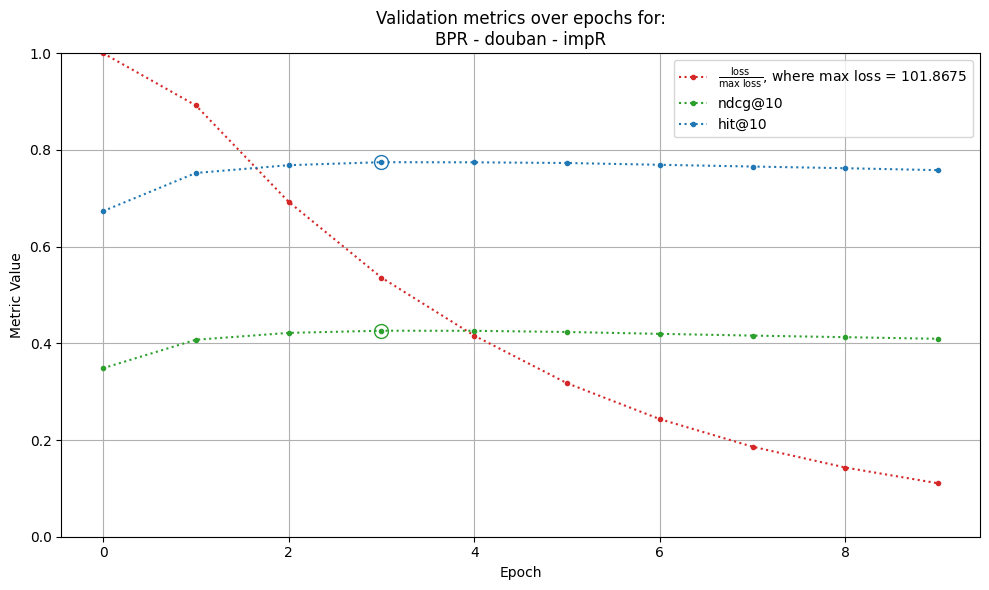

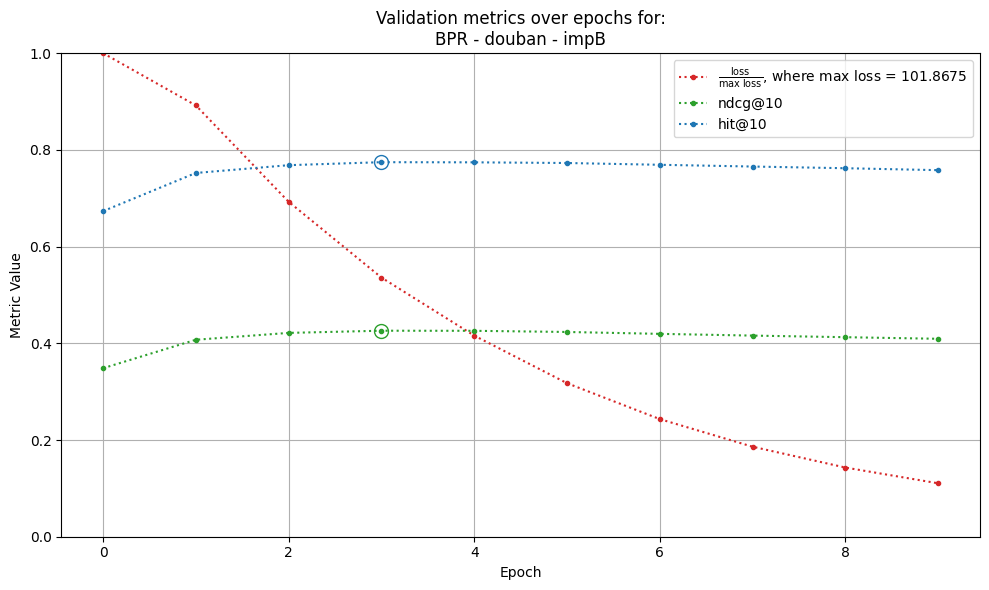

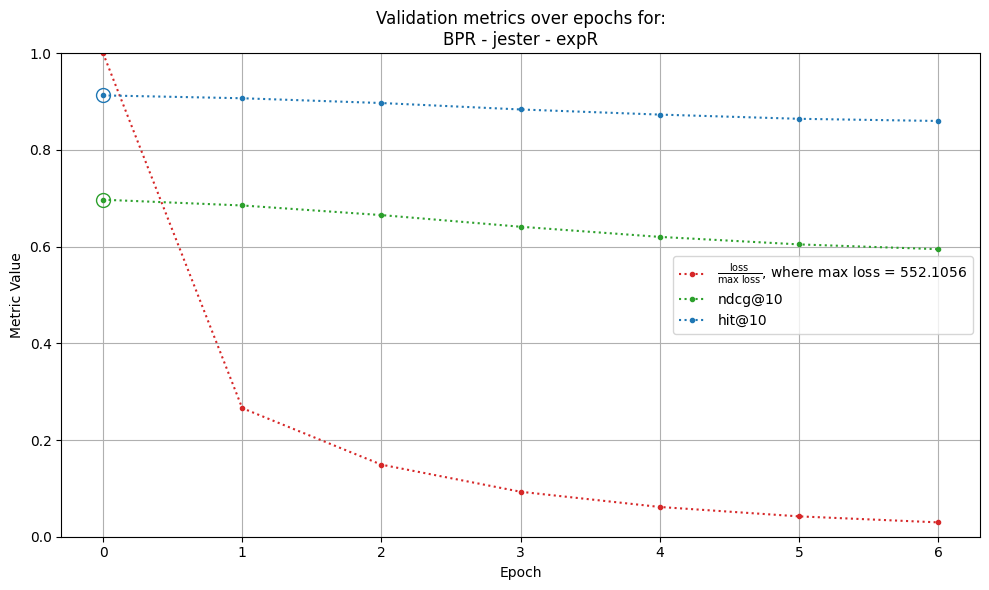

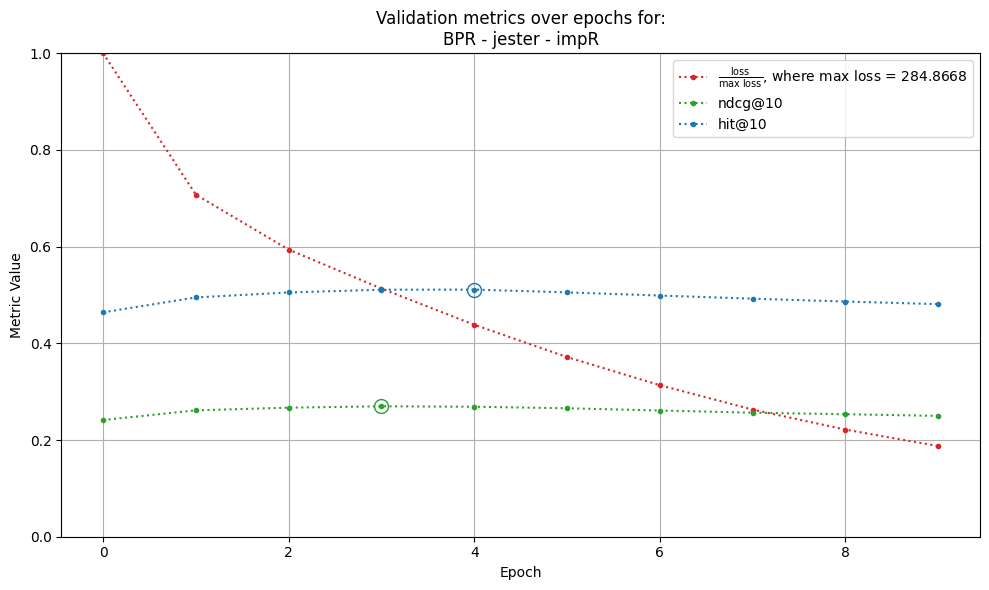

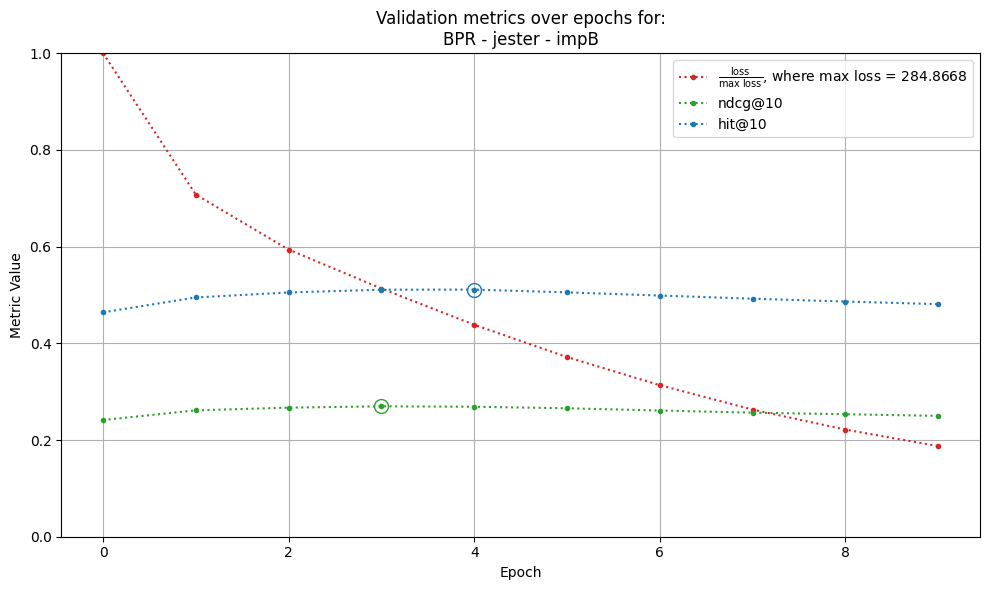

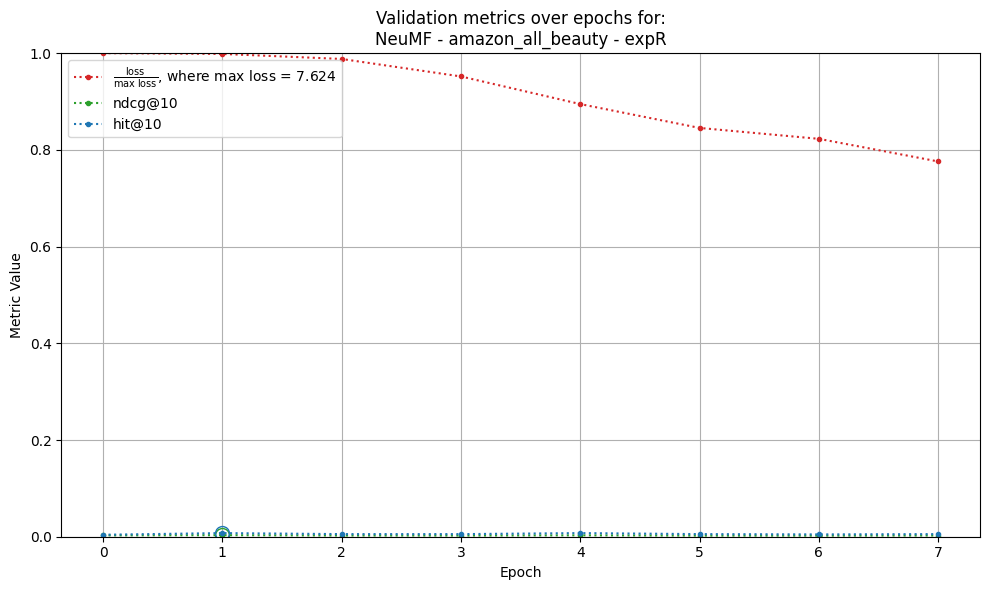

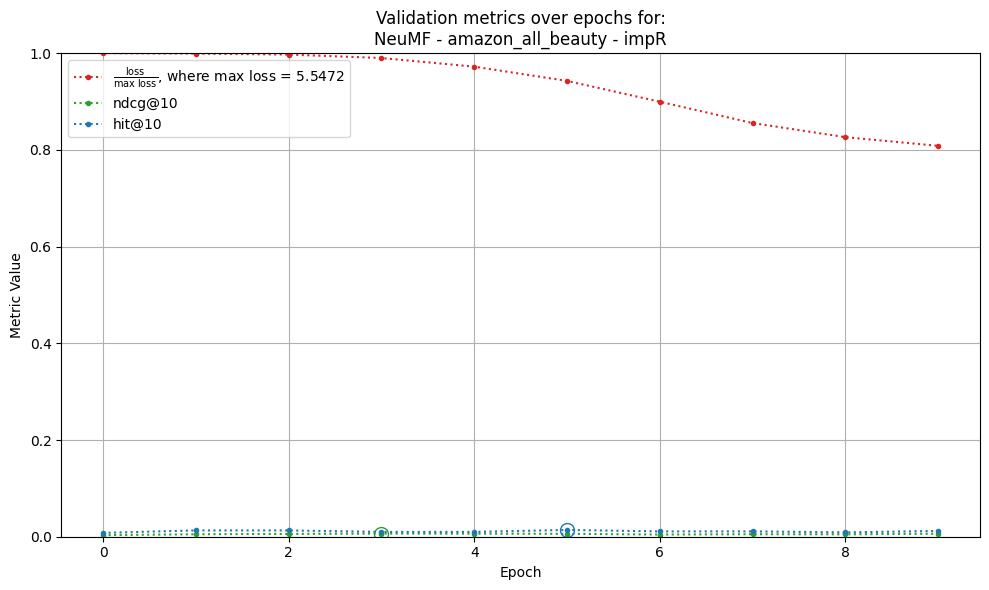

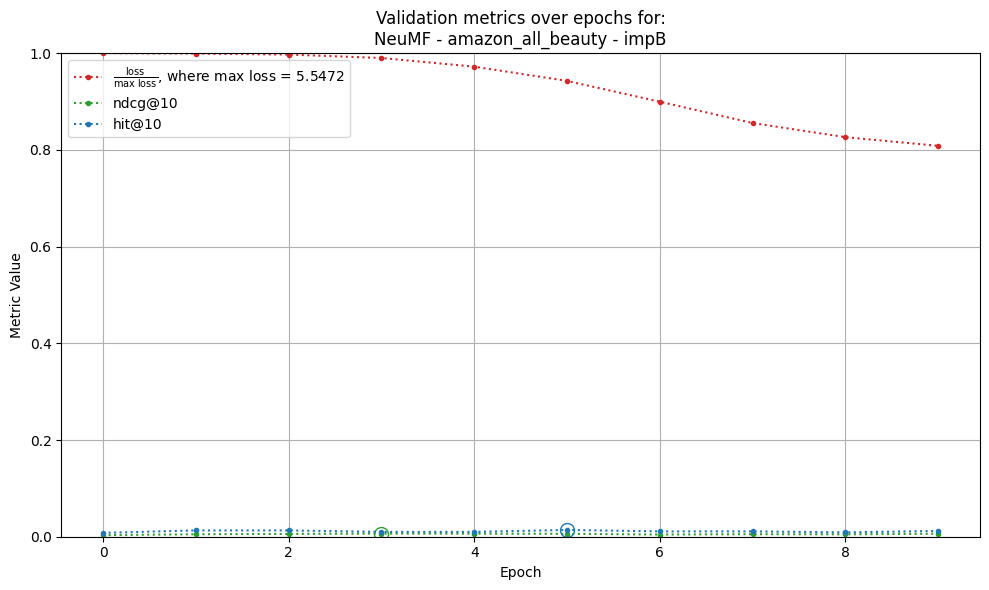

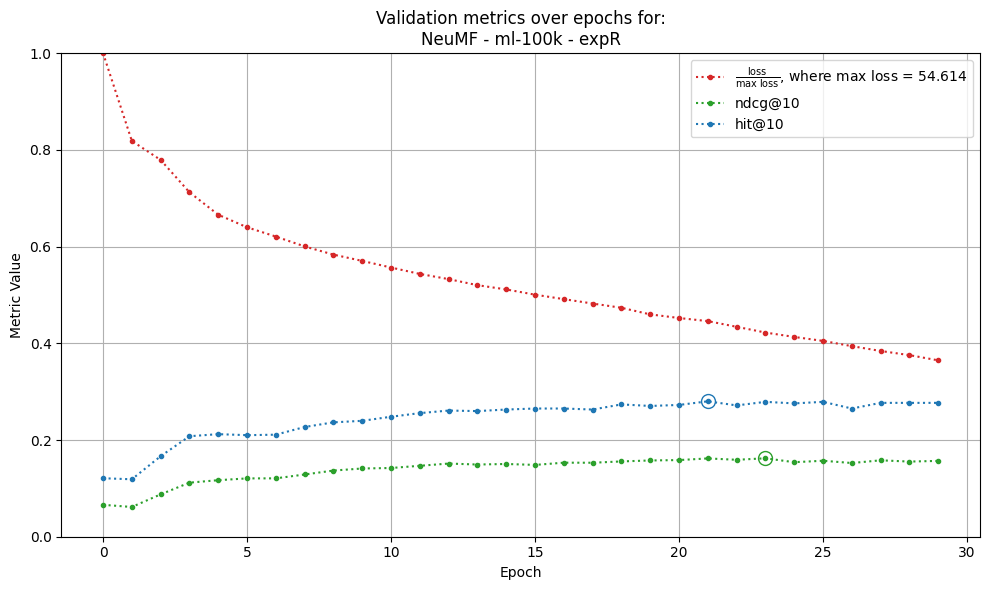

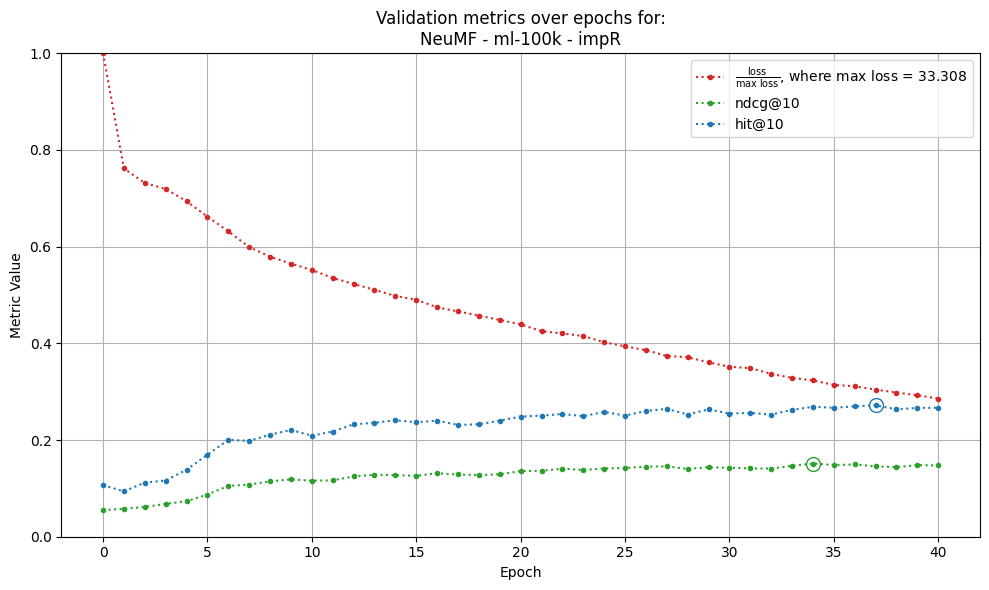

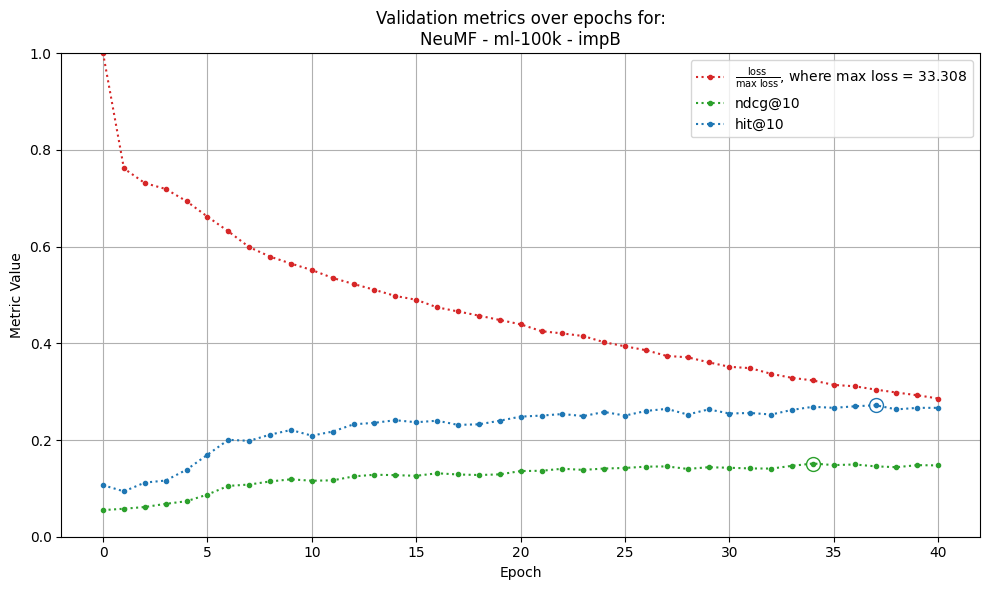

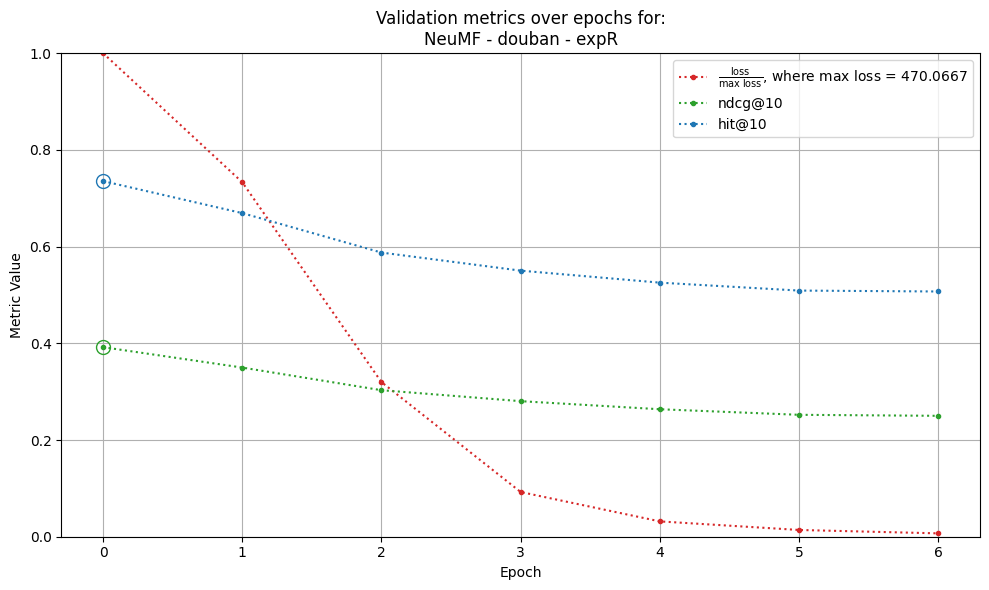

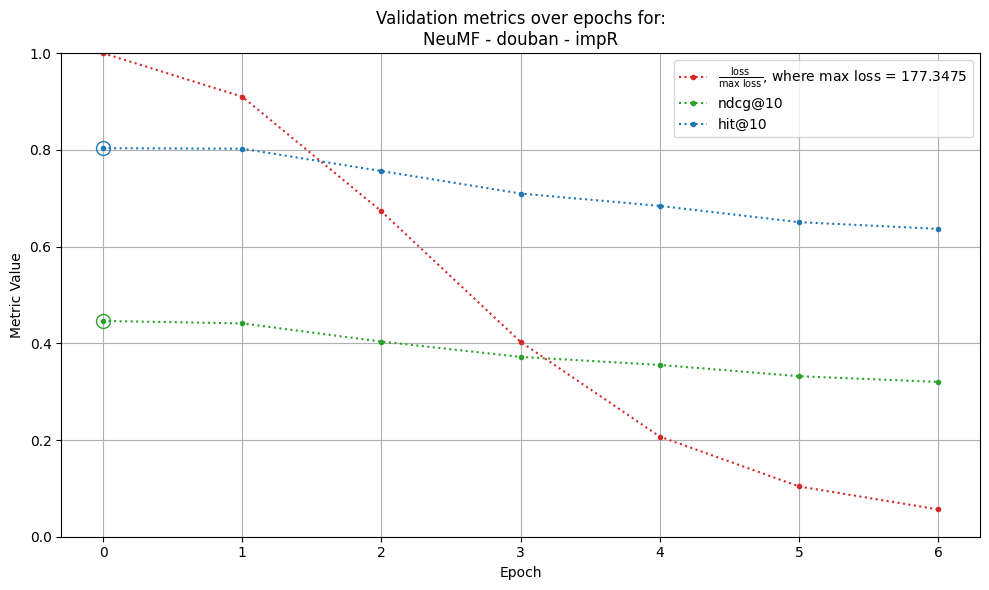

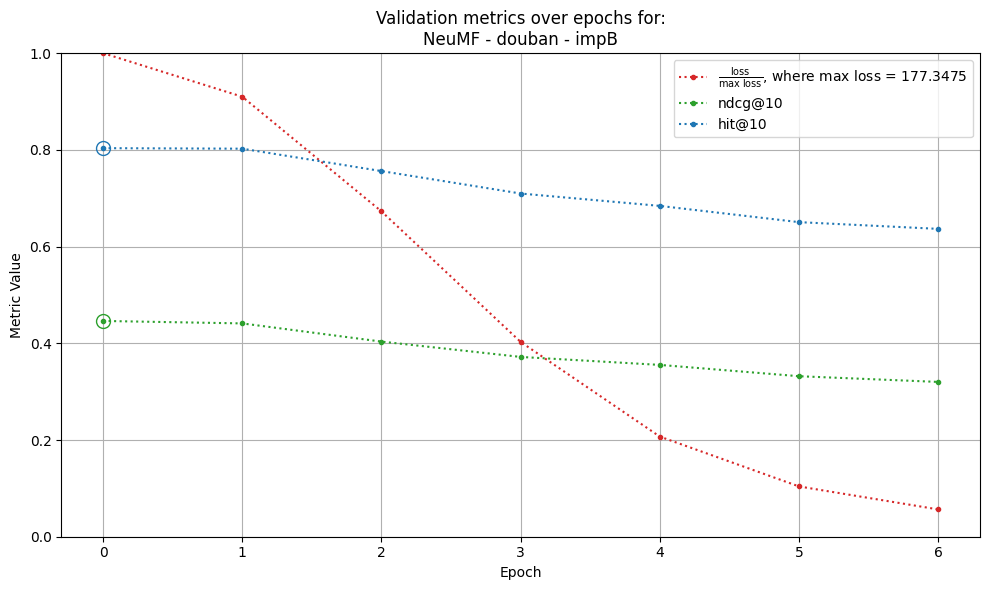

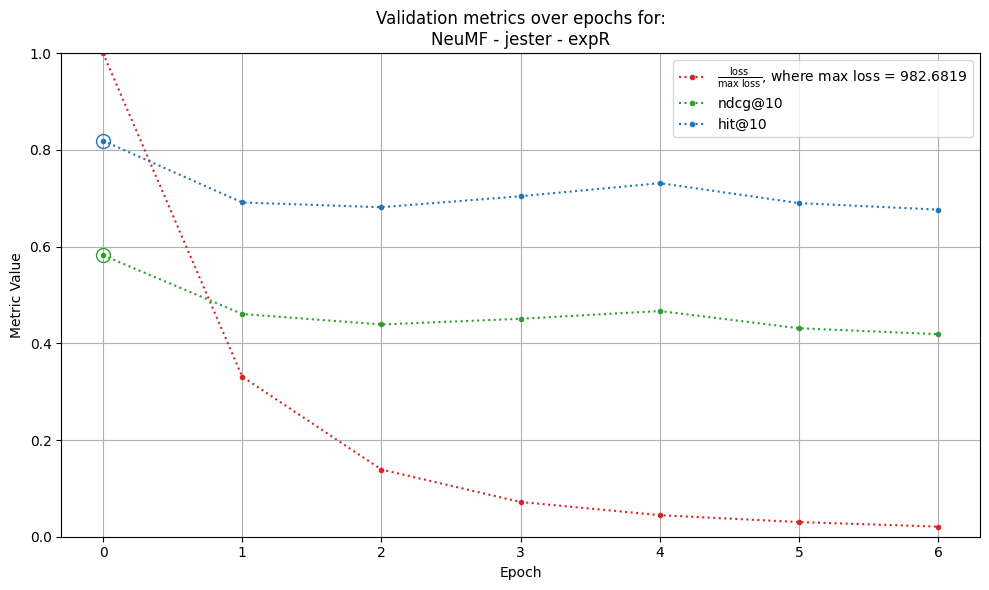

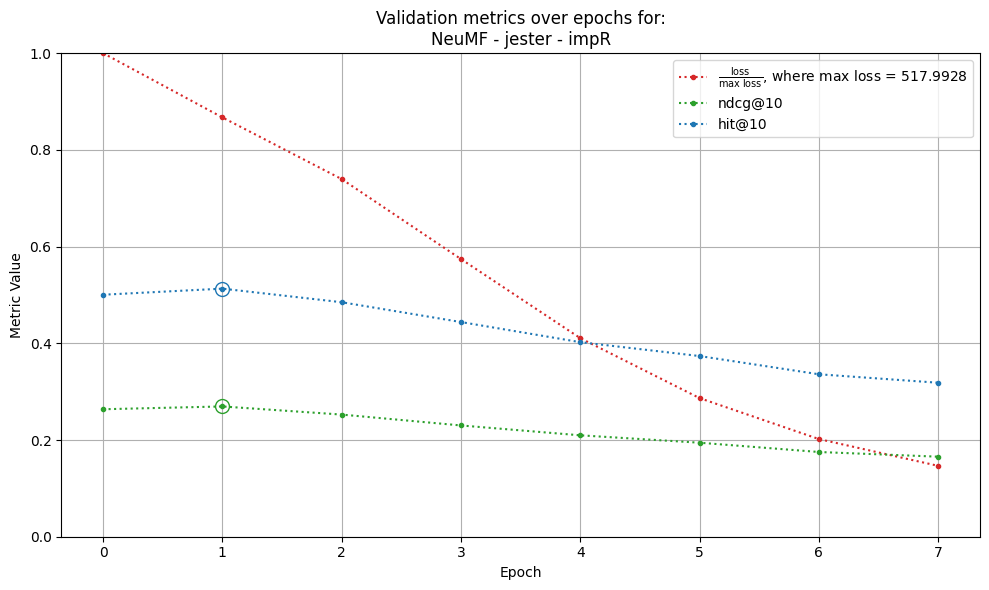

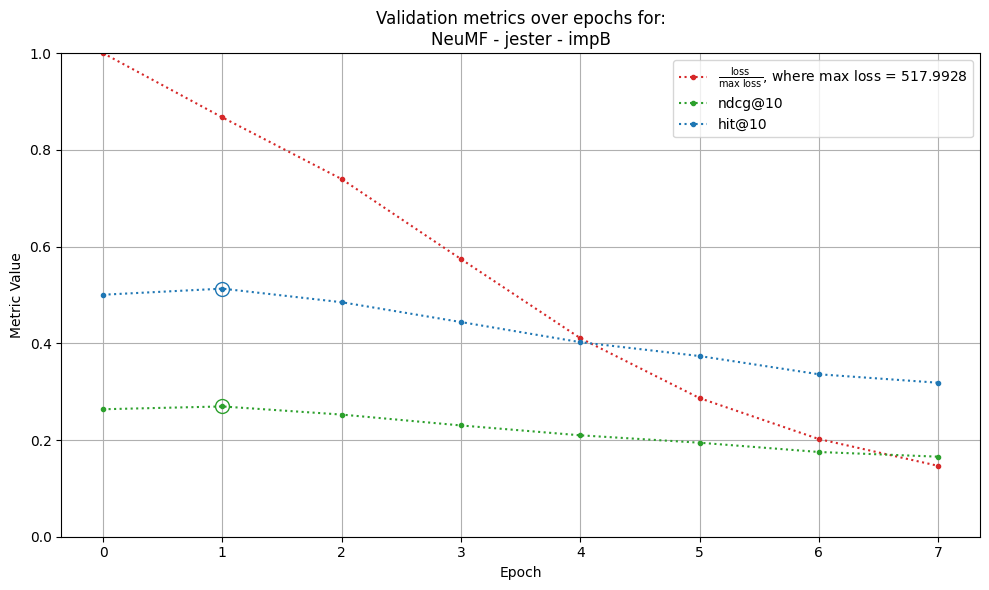

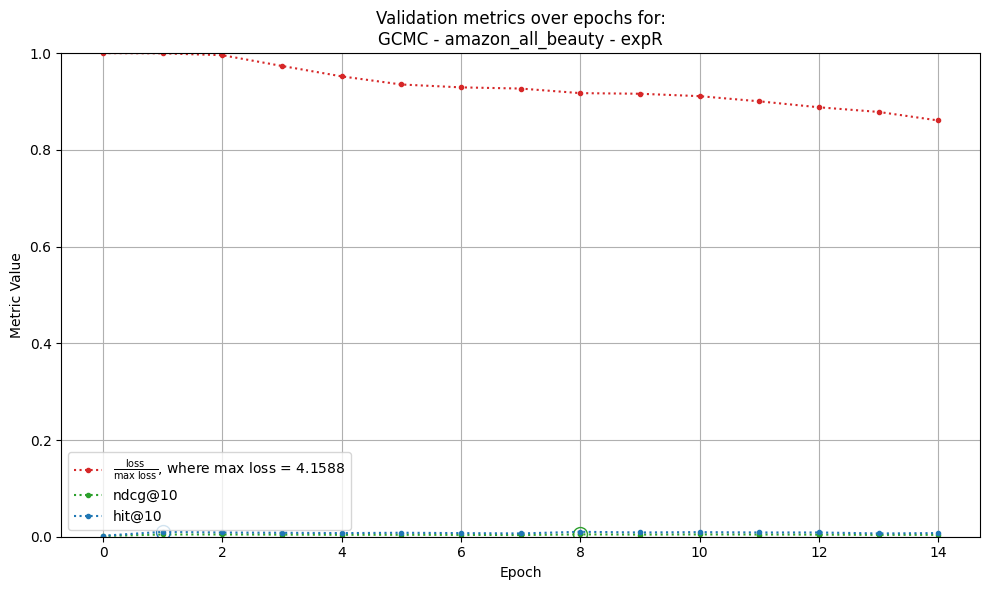

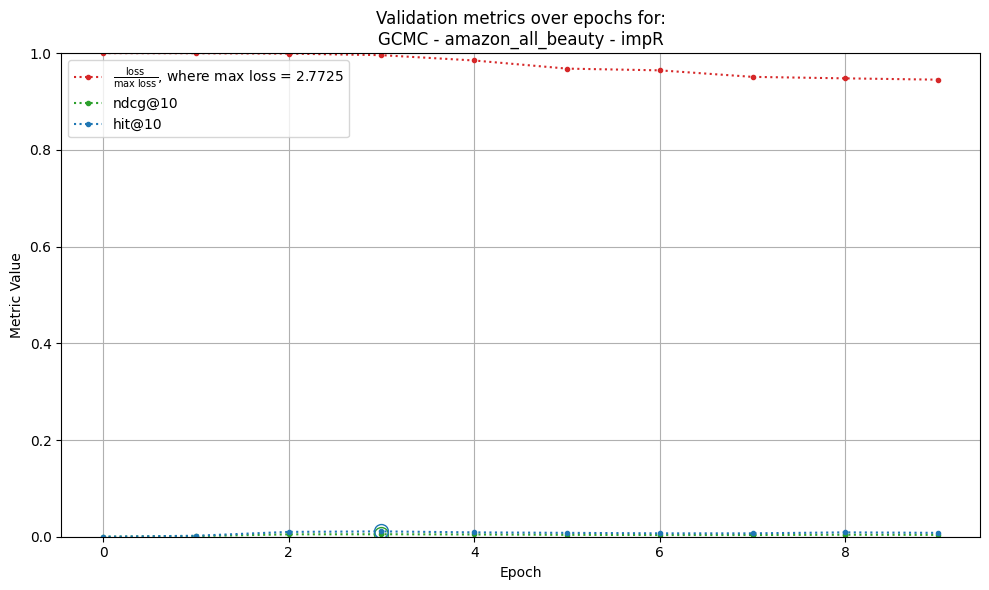

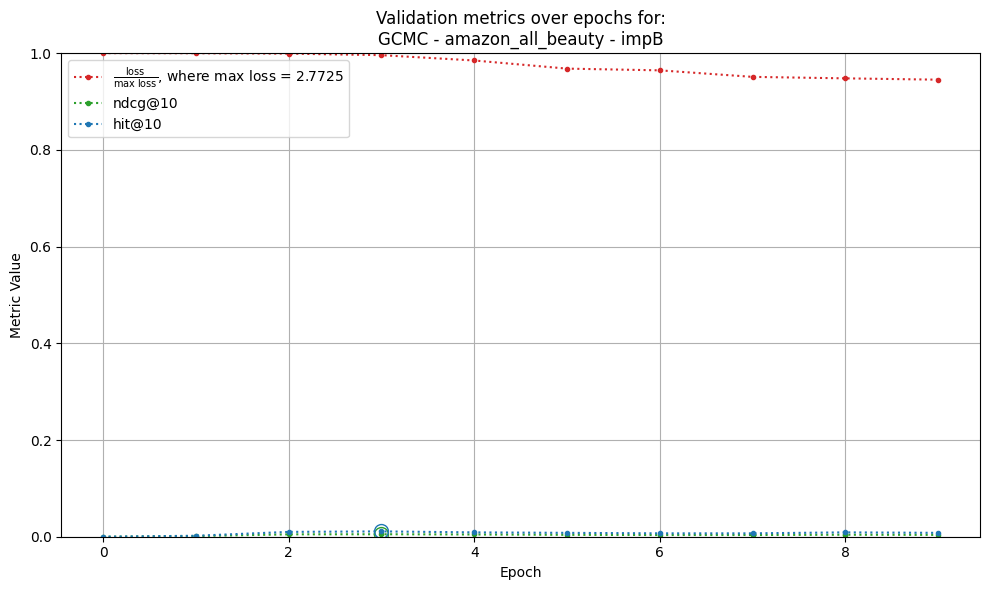

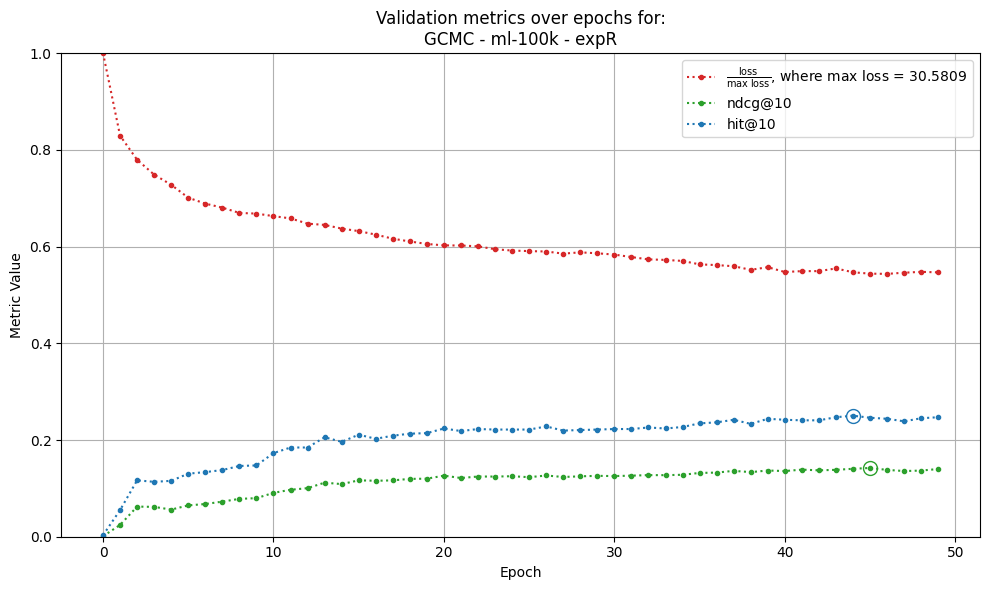

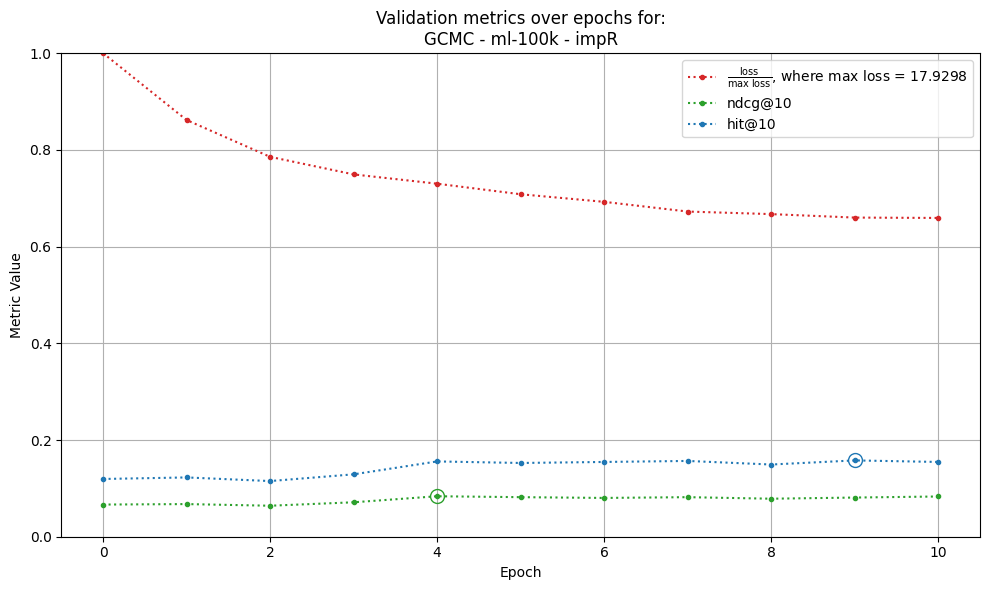

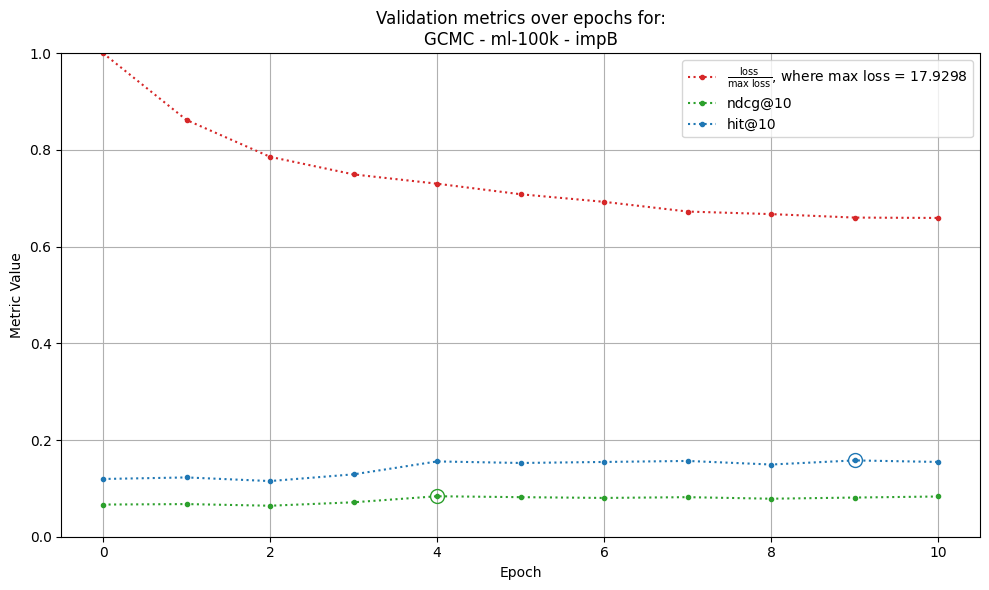

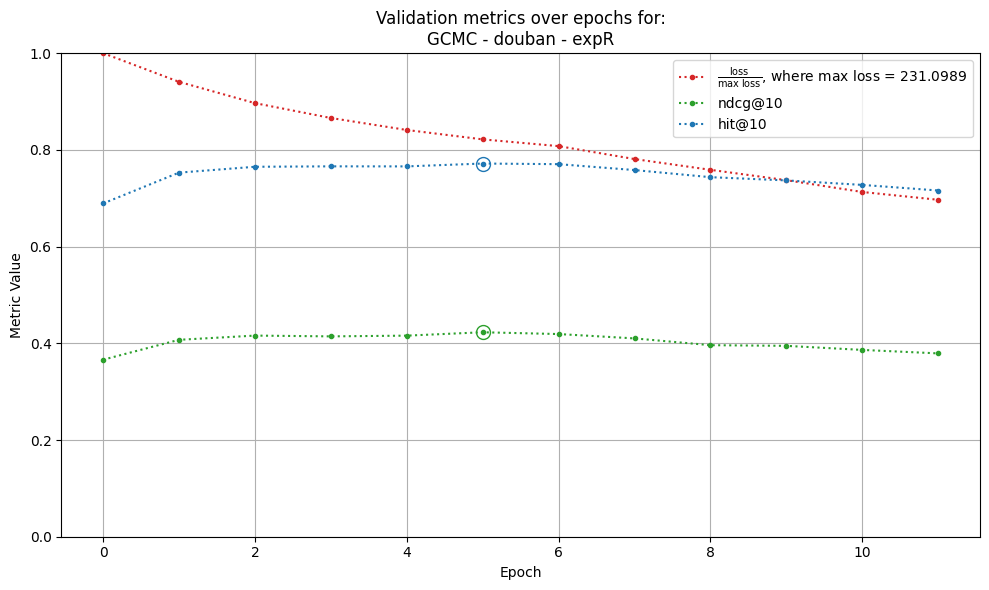

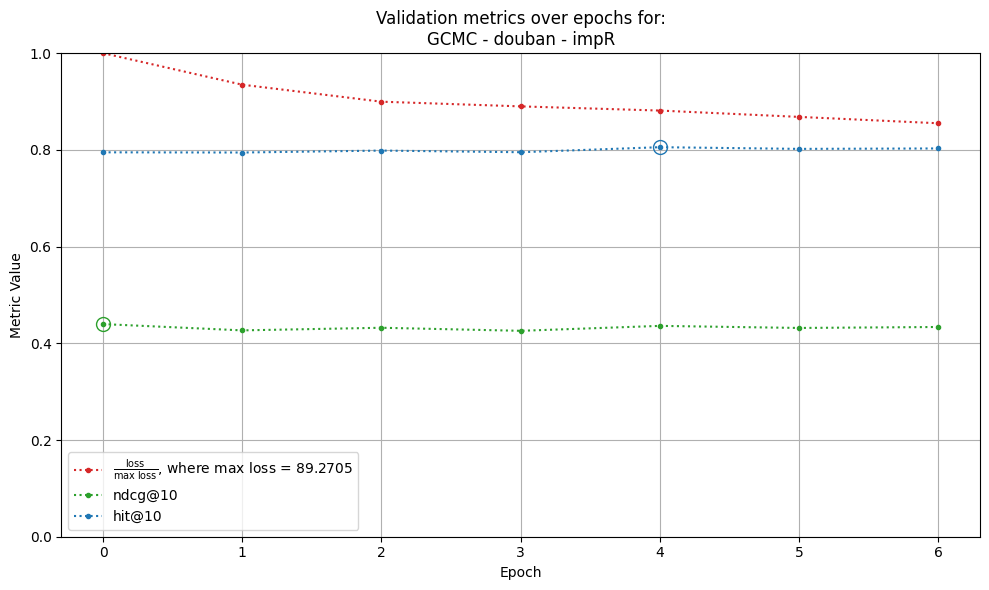

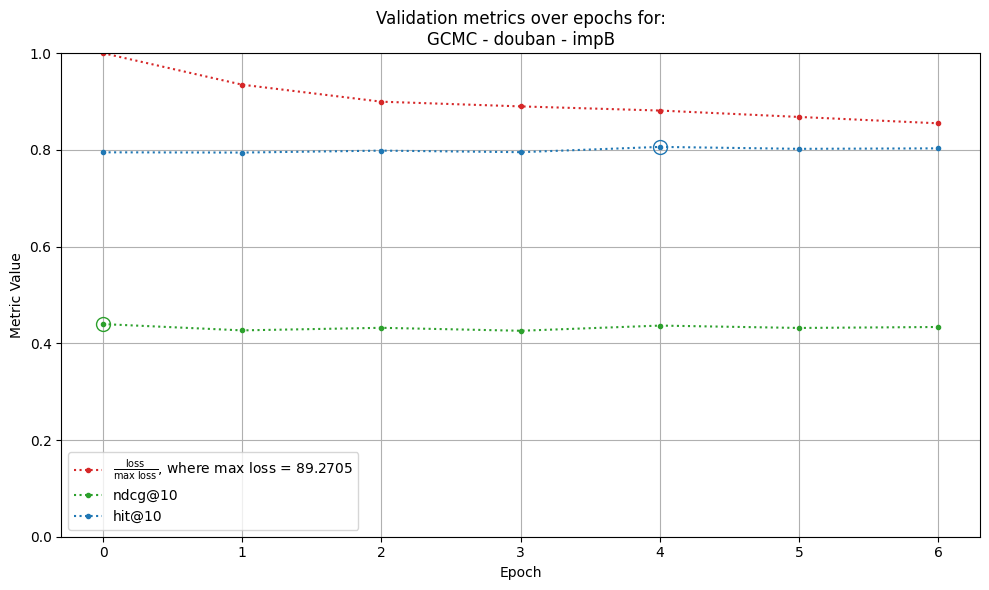

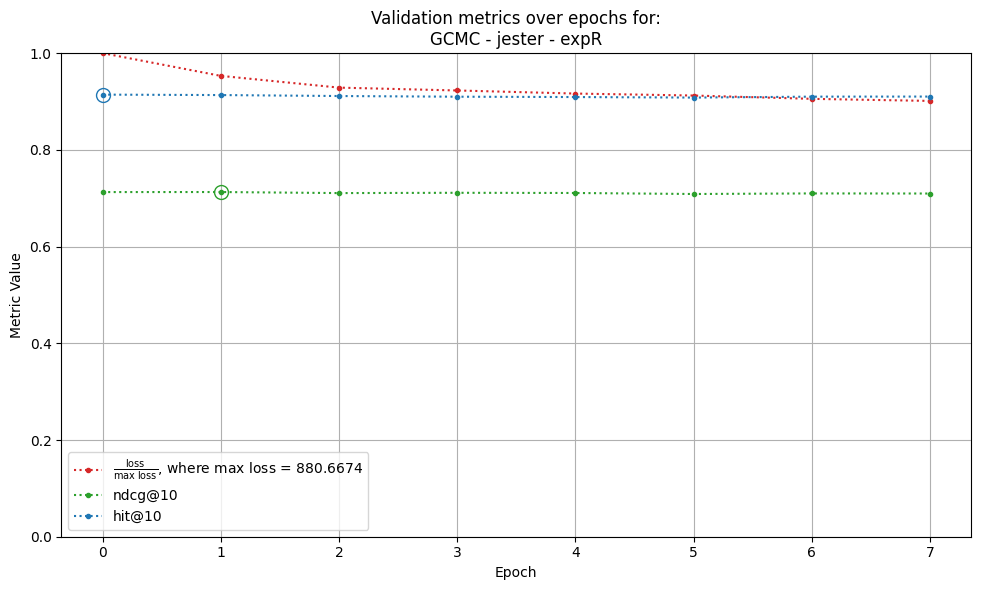

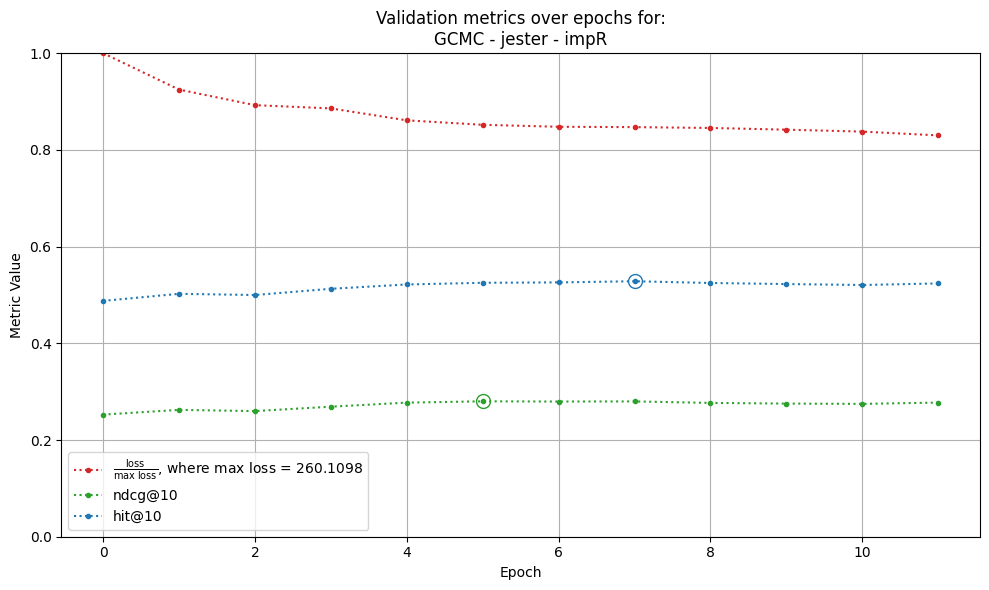

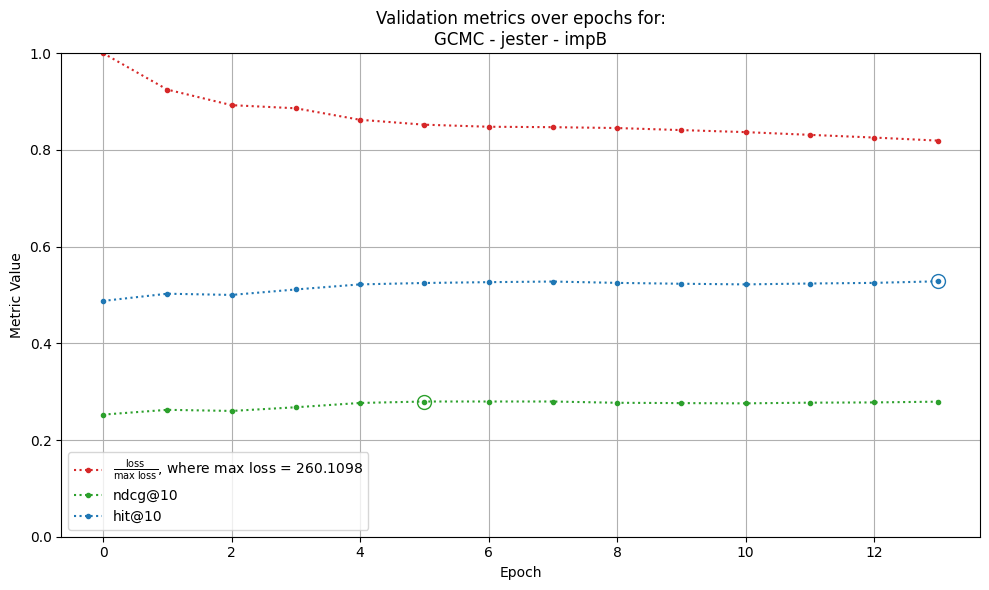

In [6]:
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt

def read_log(log_path):
    training_data = {} # To store metric values
    test_data = {} # To store test result summary

    train_time = 0.0 # To store accumulated training time (in seconds)
    eval_time = 0.0 # To store accumulated eval time (in seconds)

    trainable_params = None  # To store "Trainable parameters: xxxxxxxx"
    flops = None             # To store "FLOPs: xxxxxx.xx"

    with open(log_path, "r") as f:
        for line in f:
            # Extracting per-epoch metrics (mrr@10, recall@10, precision@10, etc.)
            metric_pattern = r"(\w+@\d+)\s*:\s*([\d.]+)"
            matches = re.findall(metric_pattern, line)
            for metric, value in matches:
                if metric not in training_data:
                    training_data[metric] = []
                training_data[metric].append(float(value))

            # Extract per-epoch Training Loss. 
            # Example: epoch 0 training [time: 282.57s, train loss: 325.2666]
            m_loss = re.search(r"train loss:\s*([\d.]+)", line)
            if m_loss:
                if 'loss' not in training_data:
                    training_data["loss"] = []
                training_data['loss'].append(float(m_loss.group(1)))

            # Extract Trainable Parameters. 
            # Example: Trainable parameters: 168128
            params_match = re.search(r"Trainable parameters:\s*([\d]+)", line)
            if params_match:
                trainable_params = int(params_match.group(1))

            # Extract FLOPs. 
            # Example: Tue 18 Nov 2025 23:07:57 INFO  FLOPs: 128.0
            flops_match = re.search(r"FLOPs:\s*([\d.]+)", line)
            if flops_match:
                flops = float(flops_match.group(1))

            # Accumulate training and evaluation time from epoch logs
            m_train = re.search(r"epoch\s+(\d+)\s+training\s+\[time:\s*([\d.]+)s", line)
            if m_train:
                train_time += float(m_train.group(2))

            m_eval = re.search(r"epoch\s+(\d+)\s+evaluating\s+\[time:\s*([\d.]+)s", line)
            if m_eval:
                eval_time += float(m_eval.group(2))

            # Match summary lines containing test results
            if "INFO  test result:" in line:
                test_data = {m[0]: float(m[1] or m[2]) for m in re.findall(r"\('([^']+)', (?:np\.float64\(([\d.]+)\)|([\d.]+))\)", line)}


    epochs = len(next(iter(training_data.values())))  # Get the number of epochs

    return training_data, test_data, train_time, eval_time, epochs, trainable_params, flops

def plot(model, dataset, datatype, training_data, epochs, save_path):
    # Define colors for each metric (up to 9 different)
    colors = ['tab:red', 'tab:green', 'tab:blue', 'tab:purple', 'tab:orange', 'tab:brown', 'tab:pink', 'tab:cyan', 'tab:gray']
    
    p_metrics = ['loss', 'ndcg@10', 'hit@10']

    X = range(epochs)

    # Plot
    plt.figure(figsize=(10, 6))
    for c, m in enumerate(p_metrics):
        if m == 'loss':
            max_val = max(training_data[m])
            if max_val != 0:
                plt.plot(X, [val/max_val for val in training_data[m]], marker='.', linestyle=':', color=colors[c % len(colors)], 
                     label= r'$\frac{\text{loss}}{\text{max loss}}$' + f', where max loss = {max_val}')
        else:
            plt.plot(X, training_data[m], marker='.', linestyle=':', color=colors[c % len(colors)],
                     label= f'{m}')
            max_x = max(X, key=lambda i: training_data[m][i])
            plt.plot(max_x, training_data[m][max_x], marker='o', color=colors[c % len(colors)], 
                     markersize=10, markerfacecolor='none', markeredgewidth=1)

    plt.title(f"Validation metrics over epochs for:\n" + 
            f"{model} - {dataset} - {datatype}")
    plt.xlabel("Epoch")
    plt.ylabel("Metric Value")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.ylim(0, 1)
    plt.savefig(save_path+f'{model}-{dataset}-{datatype}', bbox_inches='tight')
    #plt.show()


models = ['ItemKNN', 'BPR', 'NeuMF', 'GCMC']
datasets = ['ml-100k', 'jester', 'amazon_all_beauty', 'douban', 'netflix']
datatypes = ['expR', 'impR', 'impB']  
MovieLens, Jester, Amazon, Douban, Netflix = range(5)
ItemKNN, BPR, NeuMF, GCMC = range(4)
expR, impR, impB = range(3)

metrics = ['recall@10', 'precision@10', 'mrr@10', 'ndcg@10', 'hit@10'] + \
            ['recall@20', 'precision@20', 'mrr@20', 'ndcg@20', 'hit@20']
 
columns = ['model', 'dataset', 'datatype'] + metrics + ['epochs', 'avg train time', 'avg eval time', 'FLOPs', 'trainable params']
df = pd.DataFrame(columns=columns)

read_path = 'data/log/'
save_path = 'data/result/'

for m in [ItemKNN, BPR, NeuMF, GCMC]:
    for d in [Amazon, MovieLens ,Douban, Jester]:
        for t in [expR, impR, impB]:
            model = models[m]
            dataset = datasets[d]
            datatype = datatypes[t]
            # pattern: model--dataset--datatype-???.log
            log_read_pattern = read_path+f'{model}-{dataset}--{datatype}-*.log'
            for log in glob.glob(log_read_pattern):
                training_data, test_data, train_time, eval_time, epochs, trainable_params, flops = read_log(log)

                # --- Test scores ---
                row = {
                    'model': model,
                    'dataset': dataset,
                    'datatype': datatype,
                    'epochs': epochs,
                    'avg train time': round(train_time / epochs, 2),
                    'avg eval time': round(eval_time / epochs, 2),
                    'trainable_params': trainable_params, 
                    'FLOPs': flops,
                    'trainable params': trainable_params,
                }
                # fill metrics (NaN if missing)
                for x in metrics:
                    row[x] = test_data.get(x, float('NaN'))

                df.loc[len(df)] = row  # append row

                plot(model, dataset, datatype, training_data, epochs, save_path)

#print(df.head())
df.to_csv(save_path+'df.csv', sep='\t', index=False)